In [1]:
%load_ext watermark


In [2]:
import copy
import os

from matplotlib import patches
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from teeplot import teeplot as tp


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-04-26T08:32:21.244520+00:00

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

seaborn   : 0.13.2
pandas    : 2.2.3
numpy     : 2.1.2
matplotlib: 3.10.0
teeplot   : 1.4.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get(
    "NOTEBOOK_NAME", "2026-03-23-d2h-memcpy-diagnostics"
)
teeplot_subdir


'2026-03-23-d2h-memcpy-diagnostics'

## Fetch Data


In [5]:
url = "https://github.com/user-attachments/files/26186490/bookends.csv"
df = pd.read_csv(url)
print(f"{len(df)} mismatched bookend records")
df.head()


5722 mismatched bookend records


,data_hex,layer,layer_T,position
0,12e56402bb333a590001d3821406bdb9928db58b20b2e4...,1,1,309593
1,12e57802000000000001d2ec34ff658cdf668320795b06...,1,1,309598
2,12e58c02b9c608310001d58480c342799944d751680736...,1,1,309603
3,12e5a002000000000001d559ebdaccd9b14657657702a1...,1,1,309608
4,12e5b402baaff4c70001d5243d27095d96a5574b40212b...,1,1,309613


## Parse Bookends and Classify Parity Errors


In [6]:
df["start_bookend"] = df["data_hex"].str[:8].apply(int, base=16)
df["end_bookend"] = df["data_hex"].str[-8:].apply(int, base=16)
df["diff"] = df["end_bookend"] - df["start_bookend"]

df["parity_error"] = np.where(
    df["diff"] == 512,
    "+1 parity",
    np.where(df["diff"] == -512, "-1 parity", "other"),
)
print(df["parity_error"].value_counts())
df.head()


parity_error
+1 parity    3426
-1 parity    2296
Name: count, dtype: int64


,data_hex,layer,layer_T,position,start_bookend,end_bookend,diff,parity_error
0,12e56402bb333a590001d3821406bdb9928db58b20b2e4...,1,1,309593,317023234,317023746,512,+1 parity
1,12e57802000000000001d2ec34ff658cdf668320795b06...,1,1,309598,317028354,317028866,512,+1 parity
2,12e58c02b9c608310001d58480c342799944d751680736...,1,1,309603,317033474,317033986,512,+1 parity
3,12e5a002000000000001d559ebdaccd9b14657657702a1...,1,1,309608,317038594,317039106,512,+1 parity
4,12e5b402baaff4c70001d5243d27095d96a5574b40212b...,1,1,309613,317043714,317044226,512,+1 parity


## Spatial Coordinates


In [7]:
nRow = 1170
nCol = 755
df["x"] = df["position"] // nCol  # row
df["y"] = df["position"] % nCol  # column

print(f"Row range: {df['x'].min()}--{df['x'].max()}")
print(f"Col range: {df['y'].min()}--{df['y'].max()}")


Row range: 410--410
Col range: 0--248


## Plot 1 --- Spatial Distribution


teeplots/2026-03-23-d2h-memcpy-diagnostics/color=tab-red+edgecolor=none+viz=scatterplot+x=y+y=x+ext=.pdf
teeplots/2026-03-23-d2h-memcpy-diagnostics/color=tab-red+edgecolor=none+viz=scatterplot+x=y+y=x+ext=.png


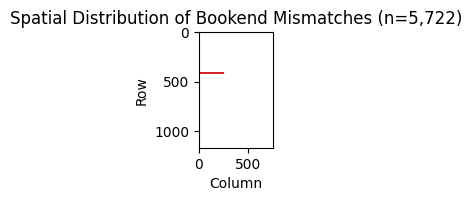

In [8]:
with tp.teed(
    sns.scatterplot,
    data=df,
    x="y",
    y="x",
    s=1,
    alpha=0.4,
    color="tab:red",
    edgecolor="none",
    legend=False,
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.set_xlim(0, nCol)
    ax.set_ylim(nRow, 0)
    ax.set_aspect("equal")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_title(
        f"Spatial Distribution of Bookend Mismatches (n={len(df):,})",
    )
    ax.figure.set_size_inches(1.5, 1.5)


## Plot 2 --- Temporal Distribution Across Layers


teeplots/2026-03-23-d2h-memcpy-diagnostics/edgecolor=none+hue=parity-error+multiple=stack+viz=histplot+weights=count+x=layer+ext=.pdf
teeplots/2026-03-23-d2h-memcpy-diagnostics/edgecolor=none+hue=parity-error+multiple=stack+viz=histplot+weights=count+x=layer+ext=.png


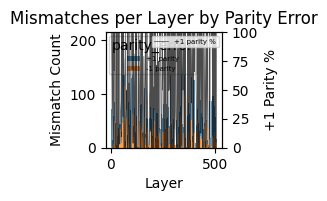

In [9]:
df_layer = (
    df.groupby(["layer", "parity_error"]).size().reset_index(name="count")
)

with tp.teed(
    sns.histplot,
    data=df_layer,
    x="layer",
    hue="parity_error",
    weights="count",
    multiple="stack",
    bins=100,
    palette=["tab:blue", "tab:orange"],
    edgecolor="none",
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.set_xlabel("Layer")
    ax.set_ylabel("Mismatch Count")
    ax.set_title("Mismatches per Layer by Parity Error")

    ax2 = ax.twinx()
    frac_data = (
        df.groupby("layer")["parity_error"]
        .apply(lambda g: (g == "+1 parity").sum() / len(g) * 100)
        .reset_index(name="frac_plus1")
    )
    ax2.plot(
        frac_data["layer"],
        frac_data["frac_plus1"],
        color="black",
        linewidth=0.5,
        alpha=0.7,
        label="+1 parity %",
    )
    ax2.set_ylabel("+1 Parity %")
    ax2.set_ylim(0, 100)
    ax2.legend(loc="upper right", fontsize=5)

    sns.move_legend(ax, "upper left", fontsize=5)
    ax.figure.set_size_inches(1.5, 1.5)


## Plot 3 --- Column Distribution Along Row 410


5722 mismatches at row 410
teeplots/2026-03-23-d2h-memcpy-diagnostics/edgecolor=none+hue=parity-error+multiple=stack+viz=histplot+x=y+ext=.pdf
teeplots/2026-03-23-d2h-memcpy-diagnostics/edgecolor=none+hue=parity-error+multiple=stack+viz=histplot+x=y+ext=.png


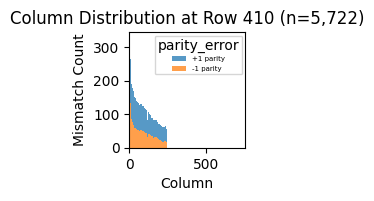

In [10]:
df_row410 = df[df["x"] == 410].copy()
print(f"{len(df_row410)} mismatches at row 410")

with tp.teed(
    sns.histplot,
    data=df_row410,
    x="y",
    hue="parity_error",
    multiple="stack",
    bins=50,
    palette=["tab:blue", "tab:orange"],
    edgecolor="none",
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.set_xlabel("Column")
    ax.set_ylabel("Mismatch Count")
    ax.set_title(f"Column Distribution at Row 410 (n={len(df_row410):,})")
    ax.set_xlim(0, nCol)
    sns.move_legend(ax, "upper right", fontsize=5)
    ax.figure.set_size_inches(1.5, 1.5)


In [11]:
df_site_faults = df.groupby(["x", "y"]).size().reset_index(name="fault_count")
print(f"{len(df_site_faults)} unique sites with faults")
df_site_faults.head()


249 unique sites with faults


,x,y,fault_count
0,410,0,21
1,410,1,72
2,410,2,83
3,410,3,79
4,410,4,74


## Plot 4 --- Fault Count Heatmap


teeplots/2026-03-23-d2h-memcpy-diagnostics/viz=heatmap+ext=.pdf
teeplots/2026-03-23-d2h-memcpy-diagnostics/viz=heatmap+ext=.png


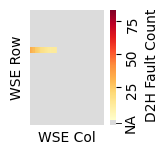

In [12]:
grid = np.full((nRow, nCol), np.nan)
grid[df_site_faults["x"].values, df_site_faults["y"].values] = df_site_faults[
    "fault_count"
].values

custom_cmap = copy.copy(plt.get_cmap("YlOrRd"))
custom_cmap.set_under("gainsboro")

with tp.teed(
    sns.heatmap,
    data=grid,
    cmap=custom_cmap,
    vmin=0.5,
    cbar_kws={
        "label": "D2H Fault Count",
        "extend": "min",
        "extendrect": True,  # <-- Turns the triangle into a rectangular box
    },
    xticklabels=False,
    yticklabels=False,
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.set_xlabel("WSE Col")
    ax.set_ylabel("WSE Row")
    ax.set_aspect("equal")
    ax.figure.set_size_inches(1.5, 1.5)

    rect = patches.Rectangle(
        (0, 0),
        nCol,
        nRow,
        linewidth=0,
        facecolor="gainsboro",
    )
    ax.add_patch(rect)

    sns.scatterplot(
        data=df_site_faults,
        x="y",
        y="x",
        hue="fault_count",
        ax=ax,
        alpha=0.3,
        edgecolor="none",
        legend=False,
        palette=custom_cmap,
        hue_norm=(0.5, df_site_faults["fault_count"].max()),
        size=0.2,
        marker=",",
    )

    # --- LABELING THE EXTENSION BOX ---
    # Grab the colorbar object that Seaborn just created
    cbar = ax.collections[0].colorbar

    # Rotate the standard tick labels 90 degrees
    cbar.ax.tick_params(axis="y", labelrotation=90)

    # Draw a manual tick mark for the zero box
    cbar.ax.plot(
        [1.0, 2],  # X coordinates: from right edge of colorbar outward
        [
            -0.025,
            -0.025,
        ],  # Y coordinates: vertically centered on the extension box
        color="black",
        linewidth=0.6,  # Matches matplotlib's default tick width
        transform=cbar.ax.transAxes,
        clip_on=False,  # Ensures the tick renders outside the colorbar bounding box
    )

    # The main colorbar y-axis runs from 0 (vmin) to 1 (vmax).
    # The 'min' extension naturally hangs below 0 (usually down to -0.05).
    # We set y=-0.025 to vertically center the label perfectly on the box.
    cbar.ax.text(
        x=2.4,  # Push to the right to align with the standard tick labels
        y=-0.025,  # Dead center of the extension box
        s="NA",
        va="center",
        ha="left",
        rotation=90,  # <-- Rotates the custom "NA" text 90 degrees
        transform=cbar.ax.transAxes,
    )
    # ax.text(
    #     20, 1150,
    #     "WSE",
    #     fontsize=15,
    #     fontweight="bold",
    #     color="white",
    #     ha="left",
    #     va="bottom",
    # )


## Plot 5 --- Fault Count Scatterplot


teeplots/2026-03-23-d2h-memcpy-diagnostics/edgecolor=none+hue=fault-count+palette=ylorrd+size=fault-count+viz=scatterplot+x=y+y=x+ext=.pdf
teeplots/2026-03-23-d2h-memcpy-diagnostics/edgecolor=none+hue=fault-count+palette=ylorrd+size=fault-count+viz=scatterplot+x=y+y=x+ext=.png


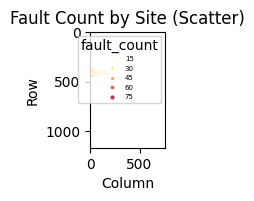

In [13]:
with tp.teed(
    sns.scatterplot,
    data=df_site_faults,
    x="y",
    y="x",
    hue="fault_count",
    size="fault_count",
    sizes=(1, 40),
    palette="YlOrRd",
    edgecolor="none",
    alpha=0.8,
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.set_xlim(0, nCol)
    ax.set_ylim(nRow, 0)
    ax.set_aspect("equal")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_title("Fault Count by Site (Scatter)")
    sns.move_legend(
        ax,
        "upper right",
        fontsize=5,
        markerscale=0.5,
    )
    ax.figure.set_size_inches(1.5, 1.5)
